In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import scipy
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

se busca la libreria NumPy para usar la herramienta en python

In [ ]:
import numpy as np

Se importa la libreria pandas para que python lo pueda analizar y ejecutar

In [ ]:
import pandas as pd

Importa Matplotlib, una biblioteca que sirve para crear gráficos y visualizar datos

In [ ]:
import matplotlib

En este código se verificó la versión de NumPy, Pandas, Matplotlib, Scikit-learn y SciPy que están instaladas en el entorno de Jupyter Notebook. Esto permite comprobar que las herramientas necesarias para realizar el trabajo están disponibles y funcionando correctamente.

In [ ]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.1
Scikit-learn: 1.9.0
SciPy: 1.18.1

En esta parte se simuló un conjunto de 300 transacciones bancarias para representar un sistema básico de detección de fraude. Se generaron datos aleatorios sobre la hora y el monto de cada transacción, asignando una mayor probabilidad de fraude a las operaciones realizadas durante la madrugada y a aquellas con montos elevados. Finalmente, los resultados se mostraron en un gráfico para observar la distribución de las transacciones legítimas y fraudulentas.

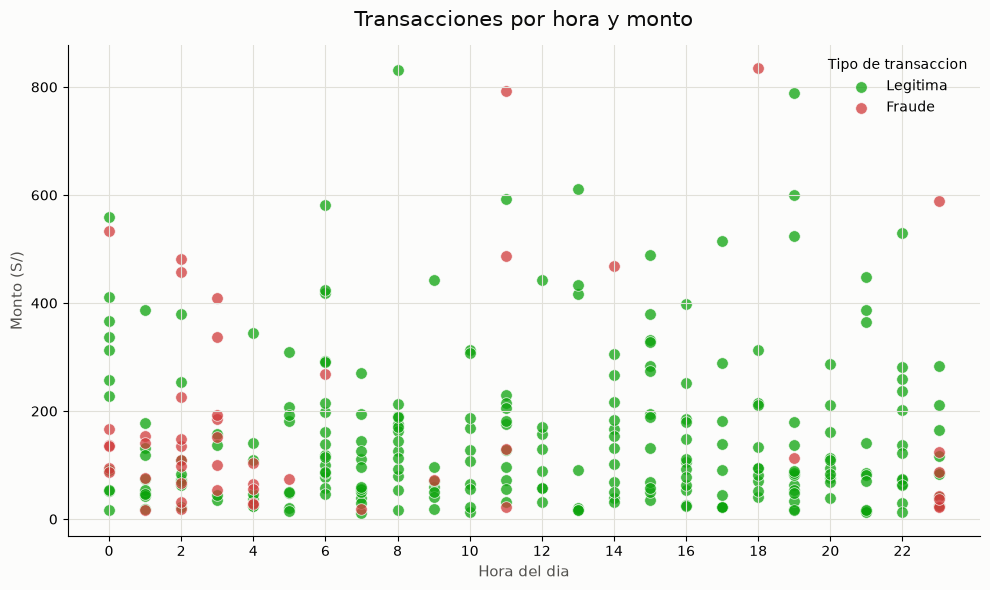

Total transacciones: 300 | Fraudes: 50


In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n = 300
hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10
# Fraude mas probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)
transacciones = pd.DataFrame({"hora": hora, "monto": monto, "es_fraude": es_fraude})
colores = {0: "#0ca30c", 1: "#d03b3b"} # verde = legitima, rojo = fraude
etiquetas = {0: "Legitima", 1: "Fraude"}
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"], subset["monto"],
        s=70, alpha=0.75,
        c=colores[valor],
        edgecolors="white", linewidths=0.6,
        label=etiquetas[valor],
)
ax.set_title("Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14)
ax.set_xlabel("Hora del dia", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transaccion", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print("Total transacciones:", len(transacciones),
"| Fraudes:", transacciones["es_fraude"].sum())


1. Parte 1: Informe de clasicación y cha PEAS

1.1. Clasicación de sistemas de IA

Sistema de reconocimiento facial

import cv2 : Se importa OpenCV, una herramienta que permite trabajar con imágenes, por ejemplo, abrirlas, modificarlas o analizarlas.
import numpy as np: Se importa NumPy, que sirve para trabajar con números, matrices y arreglos de datos. En este caso, las imágenes se pueden representar como matrices de números.
import matplotlib.pyplot as plt: Se importa Matplotlib, que permite mostrar las imágenes y crear gráficos dentro de Jupyter Notebook.
from sklearn.neighbors import KNeighborsClassifier:Se importa KNeighborsClassifier (KNN) de Scikit-learn. Este método permite clasificar datos buscando los ejemplos más parecidos y utilizando sus clases para decidir la clasificación.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

En esta parte se creó una imagen sintética de 300 × 300 píxeles con fondo blanco para utilizarla como imagen de entrada. Después, se convirtió su formato de color para poder visualizarla correctamente y se mostró en Jupyter Notebook. Esto permite comprobar que la imagen puede ser cargada y visualizada antes de realizar el proceso de clasificación.

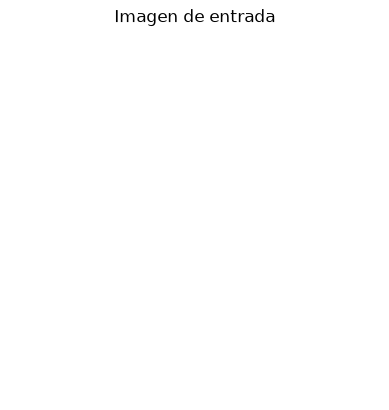

In [6]:
# Reemplaza esta línea por tu propia imagen:
# imagen = cv2.imread("ruta/a/tu_imagen.jpg")

# Para esta demo generamos una imagen sintética (fondo blanco)
imagen = np.full((300, 300, 3), 255, dtype=np.uint8)

plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen de entrada")
plt.axis("off")
plt.show()

En esta parte del código se implementó un detector de rostros utilizando OpenCV. Primero, la imagen se convirtió a escala de grises y luego se buscó si existían rostros dentro de ella. Sin embargo, como no se colocó una imagen real de una persona y se utilizó una imagen completamente en blanco, el programa no pudo detectar ningún rostro y por eso el resultado fue 0 rostros detectados.

In [7]:
def detectar_rostros(imagen):
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    rostros = detector.detectMultiScale(
        gris, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    return rostros  # lista de (x, y, ancho, alto)

rostros = detectar_rostros(imagen)
print(f"Rostros detectados: {len(rostros)}")


Rostros detectados: 0


En esta parte del código se entrenó un clasificador utilizando el método KNN para reconocer diferentes identidades. Se utilizaron datos de ejemplo que representan características faciales de dos personas llamadas Ana y Luis. El programa aprendió a diferenciar estas características y luego se comprobó que el clasificador fue entrenado correctamente con 4 muestras. En este caso, son datos simulados y no características faciales reales.

In [8]:
def entrenar_clasificador_identidad():
    # Vectores de características faciales de ejemplo (simplificados)
    X = np.array([
        [0.10, 0.20, 0.15],  # Ana - muestra 1
        [0.11, 0.19, 0.16],  # Ana - muestra 2
        [0.80, 0.75, 0.70],  # Luis - muestra 1
        [0.82, 0.77, 0.68],  # Luis - muestra 2
    ])
    y = ["Ana", "Ana", "Luis", "Luis"]

    clasificador = KNeighborsClassifier(n_neighbors=1)
    clasificador.fit(X, y)
    return clasificador

clasificador = entrenar_clasificador_identidad()
print("Clasificador entrenado con", len(clasificador._fit_X), "muestras")


Clasificador entrenado con 4 muestras


En esta parte del código se mostró el resultado de la detección y clasificación de los rostros.Sin embargo, como la imagen utilizada en la demostración estaba completamente en blanco, no se detectó ningún rostro. Por eso el programa mostró un mensaje indicando que se debe colocar una imagen real para poder probar correctamente la detección y clasificación.

No se detectaron rostros porque la imagen de la demo está en blanco.
Sube una foto real y vuelve a ejecutar la celda 3 (cv2.imread) para probarlo.


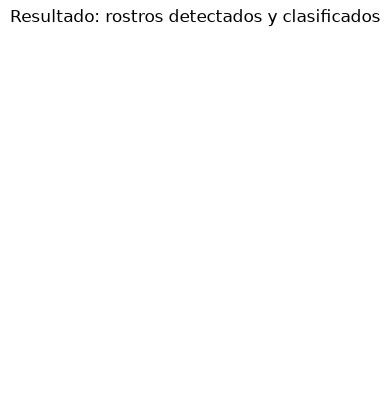

In [9]:
imagen_resultado = imagen.copy()

for (x, y, ancho, alto) in rostros:
    cv2.rectangle(imagen_resultado, (x, y), (x + ancho, y + alto), (0, 255, 0), 2)
    vector_ejemplo = [0.10, 0.20, 0.15]  # vendría de un modelo de embeddings real
    identidad = clasificador.predict([vector_ejemplo])[0]
    cv2.putText(imagen_resultado, identidad, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    print(f"Rostro en ({x},{y}) clasificado como: {identidad}")

if len(rostros) == 0:
    print("No se detectaron rostros porque la imagen de la demo está en blanco.")
    print("Sube una foto real y vuelve a ejecutar la celda 3 (cv2.imread) para probarlo.")

plt.imshow(cv2.cvtColor(imagen_resultado, cv2.COLOR_BGR2RGB))
plt.title("Resultado: rostros detectados y clasificados")
plt.axis("off")
plt.show()

Filtro anti-spam de Gmail

En esta parte del código se importaron las herramientas necesarias para trabajar con textos y realizar una clasificación. Primero se utilizó Pandas para organizar los datos, luego TF-IDF para convertir los textos en datos numéricos que la computadora pueda analizar. Después se utilizó `train_test_split` para separar los datos de entrenamiento y prueba, y `MultinomialNB` para crear un clasificador basado en Naive Bayes. Finalmente, `accuracy_score` y `classification_report` sirven para comprobar qué tan bien funciona el clasificador y mostrar sus resultados.


In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

En esta parte del código se creó un conjunto de correos de ejemplo para entrenar un sistema que pueda diferenciar entre mensajes spam y mensajes normales. Primero se escribieron varios correos con diferentes contenidos y luego se les asignó una etiqueta: `spam` para los mensajes considerados no deseados y `no_spam` para los mensajes normales. Finalmente, todos estos datos se organizaron en una tabla utilizando Pandas, donde cada correo queda relacionado con su respectiva clasificación.

In [11]:
correos = [
    "Gana dinero rapido desde casa, haz clic aqui ahora",
    "Reunion de equipo mañana a las 10am, favor confirmar asistencia",
    "Oferta exclusiva! 70% de descuento solo por hoy, compra ya",
    "Adjunto el informe mensual que pediste, saludos",
    "Eres el ganador de un premio, reclama tu dinero ahora mismo",
    "Recordatorio: la factura de este mes vence la proxima semana",
    "Felicidades, has sido seleccionado para recibir un regalo gratis",
    "Hola, ¿podemos reprogramar la llamada de proyecto para el viernes?",
    "Cialis y viagra al mejor precio, envio discreto y rapido",
    "Buenas, te comparto las notas de la reunion de ayer",
    "Ultima oportunidad para reclamar tu herencia millonaria",
    "El profesor sube las notas del examen este viernes",
    "Trabaja desde casa y gana 5000 dolares al mes sin experiencia",
    "Te espero en la oficina a las 3pm para revisar el contrato",
]

etiquetas = [
    "spam", "no_spam", "spam", "no_spam", "spam", "no_spam",
    "spam", "no_spam", "spam", "no_spam", "spam", "no_spam",
    "spam", "no_spam",
]

datos = pd.DataFrame({"correo": correos, "etiqueta": etiquetas})
datos


,correo,etiqueta
0,"Gana dinero rapido desde casa, haz clic aqui a...",spam
1,"Reunion de equipo mañana a las 10am, favor con...",no_spam
2,Oferta exclusiva! 70% de descuento solo por ho...,spam
3,"Adjunto el informe mensual que pediste, saludos",no_spam
4,"Eres el ganador de un premio, reclama tu diner...",spam
5,Recordatorio: la factura de este mes vence la ...,no_spam
6,"Felicidades, has sido seleccionado para recibi...",spam
7,"Hola, ¿podemos reprogramar la llamada de proye...",no_spam
8,"Cialis y viagra al mejor precio, envio discret...",spam
9,"Buenas, te comparto las notas de la reunion de...",no_spam


En esta parte del código se prepararon los correos para que puedan ser utilizados por el modelo de inteligencia artificial.

In [12]:
vectorizador = TfidfVectorizer()
X = vectorizador.fit_transform(datos["correo"])
y = datos["etiqueta"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Correos de entrenamiento:", X_train.shape[0])
print("Correos de prueba:", X_test.shape[0])


Correos de entrenamiento: 9
Correos de prueba: 5


en este parte del codigo se entreno el modelo de IA en el cual se utilizo un algoritmo el cual es Naive Bayes para clasificar los correos como span o no spam.

In [13]:

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
print("Precisión del modelo:", accuracy_score(y_test, predicciones))
print()
print(classification_report(y_test, predicciones, zero_division=0))


Precisión del modelo: 1.0

              precision    recall  f1-score   support

     no_spam       1.00      1.00      1.00         3
        spam       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



En esta parte del código se probaron nuevos correos con el modelo entrenado para clasificarlos como spam o no spam. Además, se mostró el nivel de confianza de cada predicción para conocer qué tan seguro está el modelo de su resultado.

In [14]:
correos_nuevos = [
    "Reclama tu premio de 10000 dolares haciendo clic aqui",
    "Hola equipo, les comparto la agenda de la reunion de hoy",
    "Descuento increible solo por hoy, no te lo pierdas",
]

X_nuevos = vectorizador.transform(correos_nuevos)
pred_nuevos = modelo.predict(X_nuevos)
prob_nuevos = modelo.predict_proba(X_nuevos)

for correo, etiqueta, prob in zip(correos_nuevos, pred_nuevos, prob_nuevos):
    confianza = max(prob) * 100
    print(f"Correo: {correo!r}")
    print(f"  -> Clasificado como: {etiqueta.upper()} (confianza: {confianza:.1f}%)\n")


Correo: 'Reclama tu premio de 10000 dolares haciendo clic aqui'
  -> Clasificado como: SPAM (confianza: 69.3%)

Correo: 'Hola equipo, les comparto la agenda de la reunion de hoy'
  -> Clasificado como: NO_SPAM (confianza: 53.7%)

Correo: 'Descuento increible solo por hoy, no te lo pierdas'
  -> Clasificado como: SPAM (confianza: 51.5%)



SISTEMA DE RECOMENDACION 

En esta parte del código se implementó un sistema de recomendación que analiza las calificaciones de varios usuarios para encontrar personas con gustos similares. Luego, usando esa información, el programa calcula qué contenidos no ha visto cada usuario y les asigna un puntaje para mostrar las 2 recomendaciones con mayor afinidad para cada persona.

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------------
# 1. ENTRADA: matriz usuario-ítem (calificaciones de 1 a 5, 0 = no visto/escuchado)
# ------------------------------------------------------------------
usuarios = ["Ana", "Luis", "Marta", "Pedro", "Sofía"]
items = ["Serie A", "Serie B", "Peli C", "Canción D", "Canción E"]

ratings = pd.DataFrame(
    [
        [5, 4, 0, 1, 0],   # Ana
        [4, 5, 0, 0, 1],   # Luis
        [0, 0, 5, 4, 4],   # Marta
        [1, 0, 4, 5, 5],   # Pedro
        [0, 1, 4, 5, 4],   # Sofía
    ],
    index=usuarios,
    columns=items,
)

print("Matriz de calificaciones (entrada):")
print(ratings, "\n")


def recomendar(usuario_objetivo: str, ratings: pd.DataFrame, top_n: int = 2):
    """
    Genera recomendaciones para un usuario usando filtrado colaborativo
    basado en similitud del coseno entre usuarios.
    """
    # 2. Calcular similitud entre usuarios (qué tan parecidos son sus gustos)
    similitud = cosine_similarity(ratings)
    similitud_df = pd.DataFrame(similitud, index=ratings.index, columns=ratings.index)

    # 3. Tomar los usuarios más parecidos al usuario objetivo (excluyéndolo a él mismo)
    similares = similitud_df[usuario_objetivo].drop(usuario_objetivo).sort_values(ascending=False)

    # 4. Predecir el puntaje de afinidad para los ítems no vistos,
    #    como promedio ponderado por similitud (esto es la "regresión")
    items_no_vistos = ratings.columns[ratings.loc[usuario_objetivo] == 0]
    puntajes = {}

    for item in items_no_vistos:
        num = sum(similares[u] * ratings.loc[u, item] for u in similares.index)
        den = sum(abs(similares[u]) for u in similares.index) or 1
        puntajes[item] = num / den

    # 5. SALIDA: ranking de ítems recomendados
    recomendaciones = sorted(puntajes.items(), key=lambda x: x[1], ------------------------------------------------------------------------------
for usuario in usuarios:
    recs = recomendar(usuario, ratings)
    print(f"Recomendaciones para {usuario}:")
    for item, puntaje in recs:
        print(f"   -> {item} (puntaje de afinidad estimado: {puntaje:.2f})")
    print()

Matriz de calificaciones (entrada):
       Serie A  Serie B  Peli C  Canción D  Canción E
Ana          5        4       0          1          0
Luis         4        5       0          0          1
Marta        0        0       5          4          4
Pedro        1        0       4          5          5
Sofía        0        1       4          5          4 

Recomendaciones para Ana:
   -> Canción E (puntaje de afinidad estimado: 2.10)
   -> Peli C (puntaje de afinidad estimado: 1.35)

Recomendaciones para Luis:
   -> Canción D (puntaje de afinidad estimado: 2.19)
   -> Peli C (puntaje de afinidad estimado: 1.31)

Recomendaciones para Marta:
   -> Serie B (puntaje de afinidad estimado: 0.81)
   -> Serie A (puntaje de afinidad estimado: 0.81)

Recomendaciones para Pedro:
   -> Serie B (puntaje de afinidad estimado: 1.12)

Recomendaciones para Sofía:
   -> Serie A (puntaje de afinidad estimado: 1.13)



1.2. Ficha PEAS de un sistemas tecnico

SISTEMA ANTIFRAUDE

En esta parte del código se importaron las herramientas necesarias para crear un modelo de clasificación. Se utilizó NumPy y Pandas para manejar los datos, Random Forest para entrenar el modelo y las otras herramientas para separar los datos y evaluar los resultados obtenidos.

In [28]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

En esta parte del código se generaron datos simulados de transacciones bancarias legítimas y fraudulentas, considerando características como el monto, la distancia, la hora y el tiempo entre compras. Luego, los datos se mezclaron y se mostró cuántas transacciones pertenecen a cada clase, para tener información preparada para entrenar el modelo de detección de fraude.

In [29]:
np.random.seed(42)

def generar_datos(n=2000):
    # Transacciones legítimas: montos moderados, cerca de casa, horas normales
    legitimas = pd.DataFrame({
        "monto": np.random.gamma(2, 40, n),                 # montos moderados
        "distancia_km": np.random.exponential(5, n),        # cerca de la ubicación habitual
        "hora": np.random.normal(15, 4, n).clip(0, 23),      # durante el día
        "minutos_desde_ultima": np.random.exponential(180, n),  # tiempo normal entre compras
        "fraude": 0,
    })

    # Transacciones fraudulentas: montos altos, lejos, horas raras, muy seguidas
    fraudulentas = pd.DataFrame({
        "monto": np.random.gamma(6, 150, n // 8),
        "distancia_km": np.random.exponential(300, n // 8),
        "hora": np.random.normal(3, 3, n // 8).clip(0, 23),
        "minutos_desde_ultima": np.random.exponential(2, n // 8),
        "fraude": 1,
    })

    datos = pd.concat([legitimas, fraudulentas], ignore_index=True)
    return datos.sample(frac=1, random_state=42).reset_index(drop=True)

datos = generar_datos()
print("Distribución de clases:")
print(datos["fraude"].value_counts())
datos.head()


Distribución de clases:
fraude
0    2000
1     250
Name: count, dtype: int64


,monto,distancia_km,hora,minutos_desde_ultima,fraude
0,29.477525,5.198049,19.687241,421.377419,0
1,95.467228,6.680524,8.078949,54.911629,0
2,202.495742,3.160797,14.680366,337.389400,0
3,105.855674,3.499300,13.619412,208.945889,0
4,28.601938,0.498269,16.748507,215.705933,0


En esta parte del código se separaron los datos en características y resultados, luego se dividieron en datos de entrenamiento y prueba para entrenar un modelo Random Forest que identifica transacciones legítimas o fraudulentas. Finalmente, el modelo realizó predicciones con los datos de prueba y se mostró un reporte para evaluar qué tan bien clasificó las transacciones.

In [30]:
X = datos[["monto", "distancia_km", "hora", "minutos_desde_ultima"]]
y = datos["fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
print(classification_report(y_test, predicciones, target_names=["legitima", "fraude"]))


              precision    recall  f1-score   support

    legitima       1.00      1.00      1.00       500
      fraude       1.00      0.98      0.99        63

    accuracy                           1.00       563
   macro avg       1.00      0.99      1.00       563
weighted avg       1.00      1.00      1.00       563



En esta parte del código se establecieron los costos de las posibles decisiones ante una transacción: aprobar, rechazar o enviar a revisión manual. Luego, el programa utiliza la probabilidad de fraude y el monto de la transacción para calcular el costo de cada opción y elegir automáticamente la acción que tenga el menor costo esperado.

In [31]:
# Costos relativos (definidos por política del banco)
COSTO_FRAUDE_NO_DETECTADO_POR_DOLAR = 1.0   # se pierde el monto completo si es fraude y se aprueba
COSTO_BLOQUEAR_CLIENTE_LEGITIMO = 15.0      # costo fijo por mal servicio (reputación)
COSTO_REVISION_MANUAL = 3.0                 # costo operativo de poner en revisión


def calcular_utilidad(prob_fraude, monto):
    """
    Utilidad esperada (negativa = costo esperado) para cada acción posible.
    El agente elegirá la acción de MENOR costo esperado.
    """
    costo_aprobar = prob_fraude * monto * COSTO_FRAUDE_NO_DETECTADO_POR_DOLAR
    costo_rechazar = (1 - prob_fraude) * COSTO_BLOQUEAR_CLIENTE_LEGITIMO
    costo_revisar = COSTO_REVISION_MANUAL  # costo fijo, independiente de la probabilidad

    return {
        "aprobar": costo_aprobar,
        "rechazar": costo_rechazar,
        "revisar_manual": costo_revisar,
    }


def decidir_accion(transaccion, modelo):
    """
    Percepción (S) -> Estimación (aprendizaje) -> Utilidad -> Acción (A)
    """
    X_input = pd.DataFrame([transaccion])
    prob_fraude = modelo.predict_proba(X_input)[0][1]

    costos = calcular_utilidad(prob_fraude, transaccion["monto"])
    accion = min(costos, key=costos.get)

    return accion, prob_fraude, costos

En esta parte del código se probaron tres tipos de transacciones: una normal, una sospechosa y una intermedia. El programa analiza cada caso, calcula la probabilidad de fraude y los costos de cada opción para finalmente elegir automáticamente si aprobar, rechazar o enviar a revisión manual.

In [32]:
casos = {
    "Compra normal en supermercado": {"monto": 45, "distancia_km": 2, "hora": 18, "minutos_desde_ultima": 600},
    "Compra sospechosa de alto monto y lejana": {"monto": 3200, "distancia_km": 800, "hora": 3, "minutos_desde_ultima": 1},
    "Compra ambigua (monto medio, algo lejos)": {"monto": 400, "distancia_km": 120, "hora": 22, "minutos_desde_ultima": 30},
}

for nombre, transaccion in casos.items():
    accion, prob, costos = decidir_accion(transaccion, modelo)
    print(f"--- {nombre} ---")
    print(f"  Percepción: {transaccion}")
    print(f"  Probabilidad de fraude estimada: {prob:.2%}")
    print(f"  Costos esperados por acción: { {k: round(v, 2) for k, v in costos.items()} }")
    print(f"  ACCIÓN ELEGIDA POR EL AGENTE: {accion.upper()}\n")


--- Compra normal en supermercado ---
  Percepción: {'monto': 45, 'distancia_km': 2, 'hora': 18, 'minutos_desde_ultima': 600}
  Probabilidad de fraude estimada: 0.00%
  Costos esperados por acción: {'aprobar': np.float64(0.0), 'rechazar': np.float64(15.0), 'revisar_manual': 3.0}
  ACCIÓN ELEGIDA POR EL AGENTE: APROBAR

--- Compra sospechosa de alto monto y lejana ---
  Percepción: {'monto': 3200, 'distancia_km': 800, 'hora': 3, 'minutos_desde_ultima': 1}
  Probabilidad de fraude estimada: 100.00%
  Costos esperados por acción: {'aprobar': np.float64(3200.0), 'rechazar': np.float64(0.0), 'revisar_manual': 3.0}
  ACCIÓN ELEGIDA POR EL AGENTE: RECHAZAR

--- Compra ambigua (monto medio, algo lejos) ---
  Percepción: {'monto': 400, 'distancia_km': 120, 'hora': 22, 'minutos_desde_ultima': 30}
  Probabilidad de fraude estimada: 61.00%
  Costos esperados por acción: {'aprobar': np.float64(244.0), 'rechazar': np.float64(5.85), 'revisar_manual': 3.0}
  ACCIÓN ELEGIDA POR EL AGENTE: REVISAR_MANUA

En esta parte del código se probó el sistema con una transacción que tiene un monto negativo, un dato que no es válido en una compra real. El resultado muestra que el agente puede tomar una decisión incorrecta porque no verifica si los datos de entrada son coherentes antes de utilizarlos.

In [33]:
transaccion_corrupta = {
    "monto": -999999999,   # error de lectura del sensor (dato imposible)
    "distancia_km": 2,
    "hora": 15,
    "minutos_desde_ultima": 200,
}

accion, prob, costos = decidir_accion(transaccion_corrupta, modelo)
print("--- Transacción con sensor corrupto (monto negativo) ---")
print(f"  Percepción: {transaccion_corrupta}")
print(f"  Probabilidad de fraude estimada: {prob:.2%}")
print(f"  Costos esperados por acción: { {k: round(v, 2) for k, v in costos.items()} }")
print(f"  ACCIÓN ELEGIDA POR EL AGENTE: {accion.upper()}")
print()
print("Observación: al multiplicar la probabilidad de fraude por un monto negativo,")
print("el costo de 'aprobar' se vuelve negativo (es decir, el agente lo interpreta")
print("como un BENEFICIO en vez de un riesgo). Esto rompe su racionalidad: el agente")
print("tomará una decisión absurda porque confía ciegamente en un dato de entrada")
print("que es físicamente imposible, sin validar la coherencia de sus propios sensores.")

--- Transacción con sensor corrupto (monto negativo) ---
  Percepción: {'monto': -999999999, 'distancia_km': 2, 'hora': 15, 'minutos_desde_ultima': 200}
  Probabilidad de fraude estimada: 0.00%
  Costos esperados por acción: {'aprobar': np.float64(-0.0), 'rechazar': np.float64(15.0), 'revisar_manual': 3.0}
  ACCIÓN ELEGIDA POR EL AGENTE: APROBAR

Observación: al multiplicar la probabilidad de fraude por un monto negativo,
el costo de 'aprobar' se vuelve negativo (es decir, el agente lo interpreta
como un BENEFICIO en vez de un riesgo). Esto rompe su racionalidad: el agente
tomará una decisión absurda porque confía ciegamente en un dato de entrada
que es físicamente imposible, sin validar la coherencia de sus propios sensores.


PARTE 2: Diseño de tres agentes inteligente

1. Agente de Credito

En esta parte del código se creó un agente que evalúa una solicitud de crédito considerando el ingreso mensual, el monto solicitado y si la persona tiene un historial moroso. Con estos datos, calcula la relación entre el monto y el ingreso y decide si el crédito se aprueba, se aprueba con condiciones o se rechaza, mostrando también el motivo de la decisión.

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.3:
            return "aprobar con condiciones", f"historial moroso pero relacion baja ({relacion:.2f} <= 0.3)"
        else:
            return "rechazar", f"historial moroso con relacion mayor a 0.3 ({relacion:.2f})"
    else:
        if relacion <= 0.5:
            return "aprobar", f"sin historial moroso y relacion baja ({relacion:.2f} <= 0.5)"
        elif relacion <= 0.8:
            return "aprobar con condiciones", f"sin historial moroso pero relacion moderada ({relacion:.2f})"
        else:
            return "rechazar", f"relacion monto/ingreso demasiado alta ({relacion:.2f} > 0.8)"


Se realizo pruebas con al menos 6 combinaciones el cual incluye un caso límite

En esta parte del código se probaron diferentes casos de solicitudes de crédito, cambiando el ingreso, el monto solicitado y el historial moroso. El programa calcula la relación entre el monto y el ingreso y, según las condiciones establecidas, determina si el crédito se aprueba, se aprueba con condiciones o se rechaza.

In [3]:
casos = [
    (3000, 1000, False),   # relacion 0.33, sin mora -> aprobar
    (2000, 1800, False),   # relacion 0.90, sin mora -> rechazar
    (2500, 1500, False),   # relacion 0.60, sin mora -> aprobar con condiciones
    (3000, 900, True),     # relacion 0.30, con mora (borde exacto) -> aprobar con condiciones
    (3000, 901, True),     # relacion justo por encima de 0.30 -> rechazar
    (5000, 2500, False),   # relacion exacta 0.50 (borde) -> aprobar
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"ingreso={ingreso}, monto={monto}, moroso={moroso} "
          f"-> relacion={monto/ingreso:.2f} => {accion.upper()} ({motivo})")

ingreso=3000, monto=1000, moroso=False -> relacion=0.33 => APROBAR (sin historial moroso y relacion baja (0.33 <= 0.5))
ingreso=2000, monto=1800, moroso=False -> relacion=0.90 => RECHAZAR (relacion monto/ingreso demasiado alta (0.90 > 0.8))
ingreso=2500, monto=1500, moroso=False -> relacion=0.60 => APROBAR CON CONDICIONES (sin historial moroso pero relacion moderada (0.60))
ingreso=3000, monto=900, moroso=True -> relacion=0.30 => APROBAR CON CONDICIONES (historial moroso pero relacion baja (0.30 <= 0.3))
ingreso=3000, monto=901, moroso=True -> relacion=0.30 => RECHAZAR (historial moroso con relacion mayor a 0.3 (0.30))
ingreso=5000, monto=2500, moroso=False -> relacion=0.50 => APROBAR (sin historial moroso y relacion baja (0.50 <= 0.5))


Simulacion y Visuallizacion de 200 solicitudes de manera aleatorias

En esta parte del código se simularon 200 solicitudes de crédito con diferentes ingresos, montos solicitados y antecedentes de mora. Luego, el agente evaluó cada solicitud y los resultados se mostraron en un gráfico con colores para diferenciar los créditos aprobados, aprobados con condiciones y rechazados.


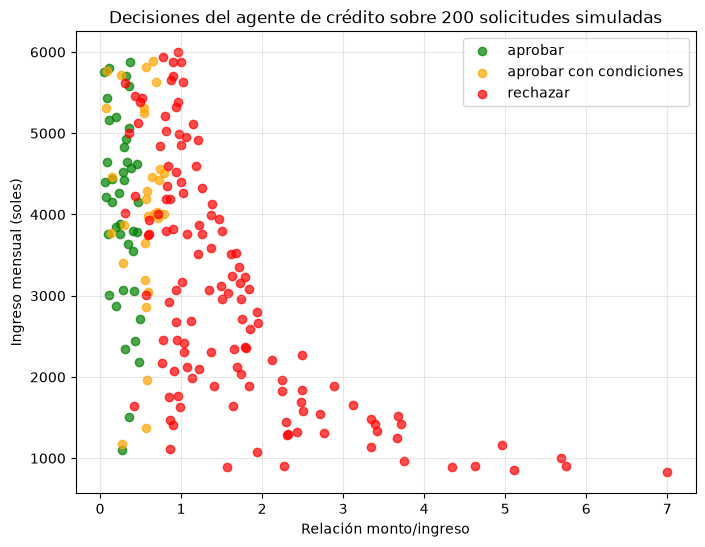

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 200

ingresos = np.random.uniform(800, 6000, n)
montos = np.random.uniform(200, 6000, n)
morosos = np.random.choice([True, False], n, p=[0.3, 0.7])

relaciones = []
acciones = []

for ingreso, monto, moroso in zip(ingresos, montos, morosos):
    accion, _ = agente_credito(ingreso, monto, moroso)
    relaciones.append(monto / ingreso)
    acciones.append(accion)

colores = {"aprobar": "green", "aprobar con condiciones": "orange", "rechazar": "red"}
plt.figure(figsize=(8, 6))

for accion in colores:
    mask = [a == accion for a in acciones]
    plt.scatter(
        np.array(relaciones)[mask],
        ingresos[mask],
        c=colores[accion],
        label=accion,
        alpha=0.7,
    )

plt.xlabel("Relación monto/ingreso")
plt.ylabel("Ingreso mensual (soles)")
plt.title("Decisiones del agente de crédito sobre 200 solicitudes simuladas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

2. Agente de Soporte

En esta parte del código se creó un agente de soporte que analiza el tiempo de espera, el nivel de urgencia y si el cliente es premium. Según estas condiciones, el sistema decide si mantener la atención en el nivel actual o escalarla a un nivel superior, indicando también el motivo de la decisión.


In [6]:
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    if nivel_urgencia == "alta":
        return "escalar a nivel 3", "urgencia alta reportada por el cliente"

    elif nivel_urgencia == "media":
        if tiempo_espera_minutos > 30 or cliente_premium:
            return "escalar a nivel 2", (
                f"urgencia media con tiempo de espera de {tiempo_espera_minutos} min "
                f"y cliente_premium={cliente_premium}"
            )
        else:
            return "mantener en nivel 1", "urgencia media con tiempo de espera bajo y cliente no premium"

    else:  # urgencia baja
        if cliente_premium and tiempo_espera_minutos > 60:
            return "escalar a nivel 2", (
                f"urgencia baja pero cliente premium con espera prolongada ({tiempo_espera_minutos} min)"
            )
        else:
            return "mantener en nivel 1", "urgencia baja sin condiciones que justifiquen escalar"


Se realizo pruebas con al menos 6 combinaciones el cual tambien incluye condiciones que no coinciden entre si

En esta parte del código se probaron diferentes situaciones de atención al cliente, cambiando el tiempo de espera, la urgencia y si el cliente es premium. El programa analiza cada caso y decide si la atención se mantiene en el nivel 1 o se escala al nivel 2 o 3, mostrando el motivo de cada decisión.


In [7]:
casos = [
    (5, "alta", False),      # urgencia alta domina -> nivel 3
    (10, "media", False),    # espera corta, no premium -> nivel 1
    (45, "media", False),    # espera larga -> nivel 2
    (5, "media", True),      # espera corta pero premium -> nivel 2
    (90, "baja", True),      # baja urgencia pero premium con espera larga -> nivel 2
    (90, "baja", False),     # baja urgencia, espera larga, no premium -> nivel 1 (contraste con el anterior)
]

for tiempo, urgencia, premium in casos:
    accion, motivo = agente_soporte(tiempo, urgencia, premium)
    print(f"tiempo={tiempo} min, urgencia={urgencia}, premium={premium} "
          f"=> {accion.upper()} ({motivo})")


tiempo=5 min, urgencia=alta, premium=False => ESCALAR A NIVEL 3 (urgencia alta reportada por el cliente)
tiempo=10 min, urgencia=media, premium=False => MANTENER EN NIVEL 1 (urgencia media con tiempo de espera bajo y cliente no premium)
tiempo=45 min, urgencia=media, premium=False => ESCALAR A NIVEL 2 (urgencia media con tiempo de espera de 45 min y cliente_premium=False)
tiempo=5 min, urgencia=media, premium=True => ESCALAR A NIVEL 2 (urgencia media con tiempo de espera de 5 min y cliente_premium=True)
tiempo=90 min, urgencia=baja, premium=True => ESCALAR A NIVEL 2 (urgencia baja pero cliente premium con espera prolongada (90 min))
tiempo=90 min, urgencia=baja, premium=False => MANTENER EN NIVEL 1 (urgencia baja sin condiciones que justifiquen escalar)


Se realizo la simulacion adicional: distribución de acciones sobre 200 tickets aleatorios

En esta parte del código se simularon 200 tickets de soporte con diferentes tiempos de espera, niveles de urgencia y tipos de clientes. Luego, el programa contó las decisiones tomadas por el agente y las mostró en un gráfico para observar cuántos casos fueron mantenidos o escalados a cada nivel.


Distribución de acciones sobre 200 tickets simulados:
mantener en nivel 1    91
escalar a nivel 2      61
escalar a nivel 3      48
Name: count, dtype: int64


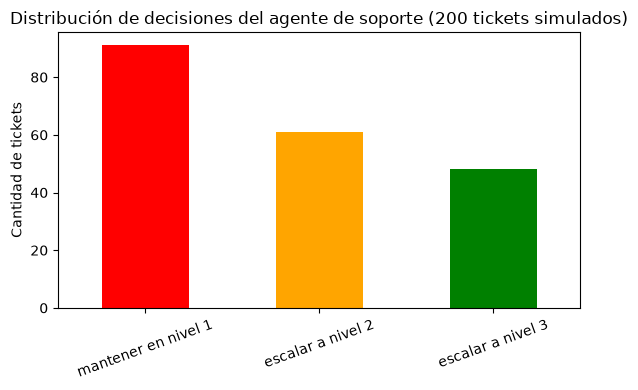

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
n = 200

tiempos = np.random.randint(0, 120, n)
urgencias = np.random.choice(["baja", "media", "alta"], n, p=[0.4, 0.4, 0.2])
premiums = np.random.choice([True, False], n, p=[0.25, 0.75])

acciones = [agente_soporte(t, u, p)[0] for t, u, p in zip(tiempos, urgencias, premiums)]

conteo = pd = __import__("pandas").Series(acciones).value_counts()
print("Distribución de acciones sobre 200 tickets simulados:")
print(conteo)

plt.figure(figsize=(6, 4))
conteo.plot(kind="bar", color=["red", "orange", "green"])
plt.ylabel("Cantidad de tickets")
plt.title("Distribución de decisiones del agente de soporte (200 tickets simulados)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

3. Agente de Inspeccion

En esta parte del código se creó un agente de inspección que analiza una imagen representada por una matriz de valores, donde `0` significa normal y `1` significa defectuoso. El programa cuenta los defectos y decide si el producto se aprueba, pasa a revisión manual o se rechaza, dependiendo de la cantidad de píxeles defectuosos encontrados.

In [9]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = int(np.sum(imagen == 1))

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos (defecto leve)"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"


# Ejemplo de imagen para probar (0 = normal, 1 = defectuoso)
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
print(agente_inspeccion(imagen_prueba))


('revision manual', 'se detectaron 3 pixeles defectuosos (defecto leve)')


Se va probar con al menos 4 matrices incluye 0 defectos y un caso limite exacto

En esta parte del código se crearon diferentes imágenes de prueba con distintas cantidades de defectos, desde ninguna hasta varios defectos. Luego, el agente analizó cada caso y decidió si el producto debía aprobarse, pasar a revisión manual o rechazarse, comprobando que las condiciones funcionen correctamente.


In [10]:
matrices_prueba = {
    "Sin defectos": np.zeros((5, 5), dtype=int),

    "1 defecto": np.array([
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),

    "Caso limite: exactamente 3 defectos": np.array([
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
    ]),

    "Caso limite: exactamente 4 defectos": np.array([
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0],
    ]),

    "Muchos defectos": np.array([
        [1, 1, 1, 0, 0],
        [1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1],
        [0, 0, 1, 1, 0],
        [1, 0, 0, 0, 0],
    ]),
}

for nombre, imagen in matrices_prueba.items():
    accion, motivo = agente_inspeccion(imagen)
    print(f"{nombre}: {accion.upper()} ({motivo})")


Sin defectos: APROBAR (no se detectaron pixeles defectuosos)
1 defecto: REVISION MANUAL (se detectaron 1 pixeles defectuosos (defecto leve))
Caso limite: exactamente 3 defectos: REVISION MANUAL (se detectaron 3 pixeles defectuosos (defecto leve))
Caso limite: exactamente 4 defectos: RECHAZAR (se detectaron 4 pixeles defectuosos)
Muchos defectos: RECHAZAR (se detectaron 10 pixeles defectuosos)


In [ ]:
Visualizacion de las imagenes de prueba

En esta parte del código se mostraron gráficamente las diferentes imágenes de prueba y la decisión tomada por el agente de inspección. Cada imagen se presenta junto con su resultado, permitiendo observar de forma sencilla cuáles fueron aprobadas, enviadas a revisión manual o rechazadas.


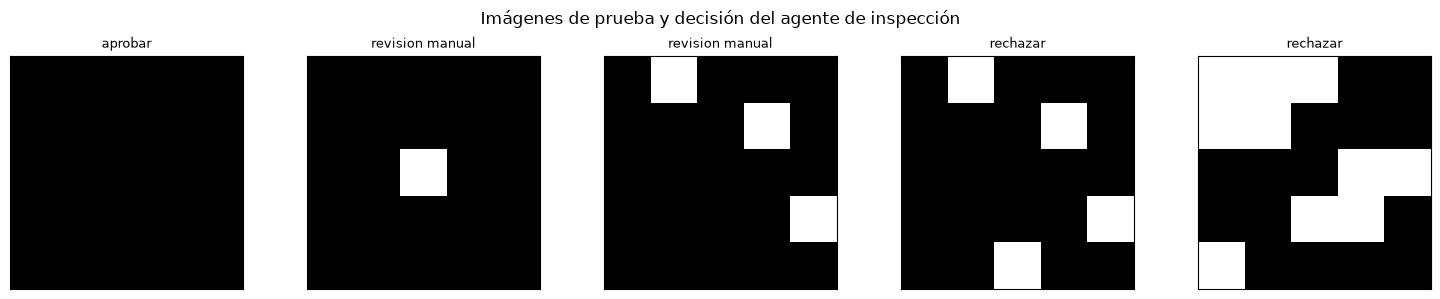

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(matrices_prueba), figsize=(15, 3))

for ax, (nombre, imagen) in zip(axes, matrices_prueba.items()):
    ax.imshow(imagen, cmap="gray")
    accion, _ = agente_inspeccion(imagen)
    ax.set_title(f"{accion}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Imágenes de prueba y decisión del agente de inspección")
plt.tight_layout()
plt.show()

2.2. Ejercicio 2: Escalamiento de tickets de soporte técnico

En esta parte del código se creó un agente de soporte que analiza el tiempo de espera, el nivel de urgencia y si el cliente es premium. Luego, según estas condiciones, decide si la atención se mantiene en el nivel 1 o se escala al nivel 2 o 3, indicando también el motivo de la decisión.

In [12]:
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    if nivel_urgencia == "alta":
        return "escalar a nivel 3", "urgencia alta reportada por el cliente"

    elif nivel_urgencia == "media":
        if tiempo_espera_minutos > 30 or cliente_premium:
            return "escalar a nivel 2", (
                f"urgencia media con tiempo de espera de {tiempo_espera_minutos} min "
                f"y cliente_premium={cliente_premium}"
            )
        else:
            return "mantener en nivel 1", "urgencia media con tiempo de espera bajo y cliente no premium"

    else:  # urgencia baja
        if cliente_premium and tiempo_espera_minutos > 60:
            return "escalar a nivel 2", (
                f"urgencia baja pero cliente premium con espera prolongada ({tiempo_espera_minutos} min)"
            )
        else:
            return "mantener en nivel 1", "urgencia baja sin condiciones que justifiquen escalar"

Se va probar 6 condiciones el cual incluye condiciones que no coinciden

En esta parte del código se probaron diferentes casos de atención al cliente, variando el tiempo de espera, el nivel de urgencia y si el cliente es premium. Luego, el agente analiza cada caso y muestra si la atención se mantiene en el nivel 1 o se escala al nivel 2 o 3, junto con el motivo de la decisión.

In [13]:
casos = [
    (5, "alta", False),      # urgencia alta domina -> nivel 3
    (10, "media", False),    # espera corta, no premium -> nivel 1
    (45, "media", False),    # espera larga -> nivel 2
    (5, "media", True),      # espera corta pero premium -> nivel 2
    (90, "baja", True),      # baja urgencia pero premium con espera larga -> nivel 2
    (90, "baja", False),     # baja urgencia, espera larga, no premium -> nivel 1 (contraste)
]

for tiempo, urgencia, premium in casos:
    accion, motivo = agente_soporte(tiempo, urgencia, premium)
    print(f"tiempo={tiempo} min, urgencia={urgencia}, premium={premium} "
          f"=> {accion.upper()} ({motivo})")

tiempo=5 min, urgencia=alta, premium=False => ESCALAR A NIVEL 3 (urgencia alta reportada por el cliente)
tiempo=10 min, urgencia=media, premium=False => MANTENER EN NIVEL 1 (urgencia media con tiempo de espera bajo y cliente no premium)
tiempo=45 min, urgencia=media, premium=False => ESCALAR A NIVEL 2 (urgencia media con tiempo de espera de 45 min y cliente_premium=False)
tiempo=5 min, urgencia=media, premium=True => ESCALAR A NIVEL 2 (urgencia media con tiempo de espera de 5 min y cliente_premium=True)
tiempo=90 min, urgencia=baja, premium=True => ESCALAR A NIVEL 2 (urgencia baja pero cliente premium con espera prolongada (90 min))
tiempo=90 min, urgencia=baja, premium=False => MANTENER EN NIVEL 1 (urgencia baja sin condiciones que justifiquen escalar)


2.3. Ejercicio 3: Inspección visual de un producto

En esta parte del código se creó un agente de inspección que analiza una imagen representada por una matriz de 5x5, donde 0 representa una parte normal y 1 una parte defectuosa. Luego, el programa cuenta los defectos encontrados y determina si la imagen se aprueba, pasa a revisión manual o se rechaza según la cantidad de defectos.

In [14]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = int(np.sum(imagen == 1))

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos (defecto leve)"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"


# Ejemplo de imagen para probar (0 = normal, 1 = defectuoso)
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
print(agente_inspeccion(imagen_prueba))

('revision manual', 'se detectaron 3 pixeles defectuosos (defecto leve)')


Se va probar 5 matrices el cual va incluir 0 defectos y el borde exacto entre revision y rechazo

En esta parte del código se crearon diferentes matrices de prueba con distintas cantidades de defectos, desde ninguna hasta varios defectos. Luego, el agente analiza cada caso y determina si se debe aprobar, enviar a revisión manual o rechazar, comprobando que las condiciones establecidas funcionen correctamente.

In [15]:
matrices_prueba = {
    "Sin defectos": np.zeros((5, 5), dtype=int),

    "1 defecto": np.array([
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
    ]),

    "Caso limite: exactamente 3 defectos": np.array([
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
    ]),

    "Caso limite: exactamente 4 defectos": np.array([
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0],
    ]),

    "Muchos defectos": np.array([
        [1, 1, 1, 0, 0],
        [1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1],
        [0, 0, 1, 1, 0],
        [1, 0, 0, 0, 0],
    ]),
}

for nombre, imagen in matrices_prueba.items():
    accion, motivo = agente_inspeccion(imagen)
    print(f"{nombre}: {accion.upper()} ({motivo})")

Sin defectos: APROBAR (no se detectaron pixeles defectuosos)
1 defecto: REVISION MANUAL (se detectaron 1 pixeles defectuosos (defecto leve))
Caso limite: exactamente 3 defectos: REVISION MANUAL (se detectaron 3 pixeles defectuosos (defecto leve))
Caso limite: exactamente 4 defectos: RECHAZAR (se detectaron 4 pixeles defectuosos)
Muchos defectos: RECHAZAR (se detectaron 10 pixeles defectuosos)


por ultimo visualizamos

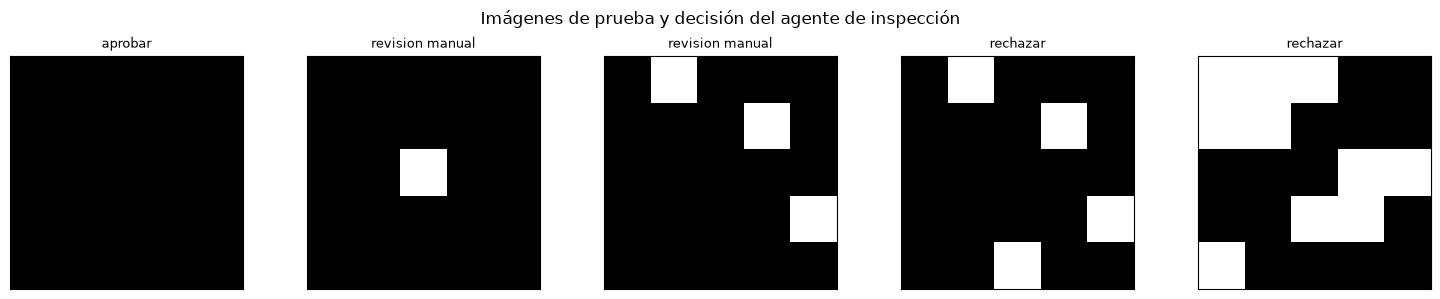

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(matrices_prueba), figsize=(15, 3))

for ax, (nombre, imagen) in zip(axes, matrices_prueba.items()):
    ax.imshow(imagen, cmap="gray")
    accion, _ = agente_inspeccion(imagen)
    ax.set_title(f"{accion}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Imágenes de prueba y decisión del agente de inspección")
plt.tight_layout()
plt.show()